In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('orders.csv')


# Clean column names to remove any extra spaces
df.columns = df.columns.str.strip()

In [3]:
# 2. Calculate the total order value for "John Doe", but only include orders greater than $100.
john_doe_relevant_orders = df[
    (df['Customer Name'] == 'John Doe') & 
    (df['Order Amount'] > 100)
]
total_john_doe = john_doe_relevant_orders['Order Amount'].sum()
print(f"Total order value for John Doe (orders > $100): ${total_john_doe}")

Total order value for John Doe (orders > $100): $890


In [4]:
# 3. Identify the country with the highest total revenue, but only include orders where the amount is greater than $100 in your calculation.
high_value_orders = df[df['Order Amount'] > 100]
country_revenue = high_value_orders.groupby('Country')['Order Amount'].sum()
highest_revenue_country = country_revenue.idxmax()
highest_revenue_amount = country_revenue.max()
print(f"Country with highest total revenue (orders > $100): {highest_revenue_country} (${highest_revenue_amount})")

Country with highest total revenue (orders > $100): USA ($4680)


In [5]:
# 4. Calculate the average order amount across all orders over $100
average_order_amount = high_value_orders['Order Amount'].mean()
print(f"Average order amount (orders > $100): ${average_order_amount:.2f}")

Average order amount (orders > $100): $193.15


Chart saved to revenue_by_country.png


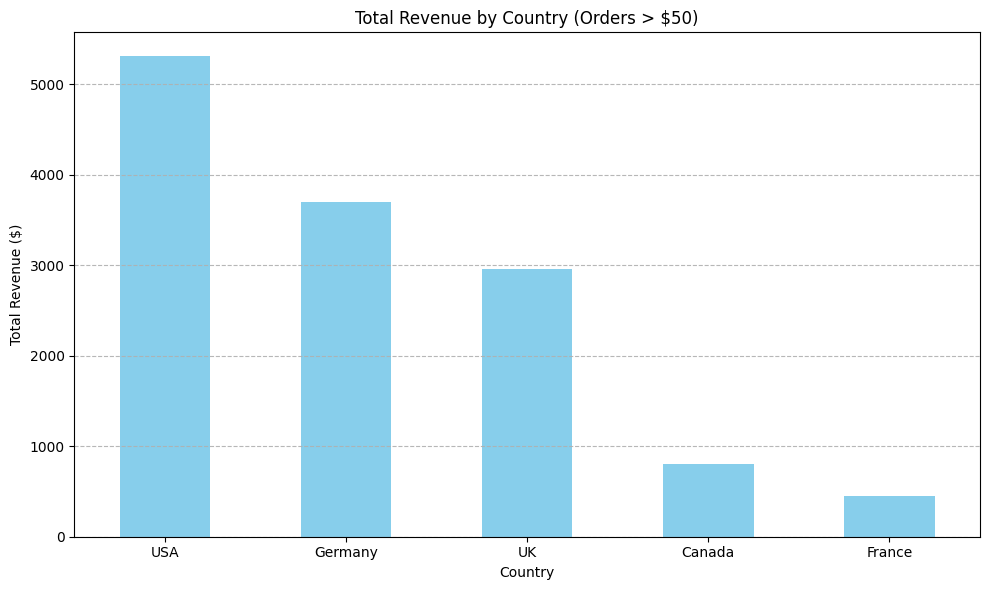

In [10]:
# 5. Create a bar chart showing total revenue by country, using only orders over $50.
orders_over_50 = df[df['Order Amount'] > 50]
country_revenue_50 = orders_over_50.groupby('Country')['Order Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
country_revenue_50.plot(kind='bar', color='skyblue', rot=0)
plt.title('Total Revenue by Country (Orders > $50)')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('revenue_by_country.png')
print("Chart saved to revenue_by_country.png")
plt.show()